In [1]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import shap

# 1. Load the features
X_train_smote = pd.read_csv('processed_data/X_train_smote.csv')
X_test = pd.read_csv('processed_data/X_test.csv')

# 2. Load the targets 

y_train_smote = pd.read_csv('processed_data/y_train_smote.csv')['target']
y_test = pd.read_csv('processed_data/y_test.csv')['target']

print(f"Training shape: {X_train_smote.shape}")
print(f"Testing shape: {X_test.shape}")



Training shape: (6454, 25)
Testing shape: (913, 25)


# Model fitting and training

In [2]:
# ==========================================
# 1. Logistic Regression Tuning
# ==========================================
print("Tuning Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10], # Regularization strength
    'solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=5, scoring='f1')
lr_grid.fit(X_train_smote, y_train_smote)
best_lr = lr_grid.best_estimator_

# ==========================================
# 2. K-Nearest Neighbors (K-NN) Tuning
# ==========================================
print("Tuning K-NN...")
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='f1')
knn_grid.fit(X_train_smote, y_train_smote)
best_knn = knn_grid.best_estimator_

# ==========================================
# 3. LightGBM Tuning
# ==========================================
print("Tuning LightGBM...")
lgbm_params = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    
   
    'num_leaves': [7,  15]
}
lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), lgbm_params, cv=5, scoring='f1')
lgbm_grid.fit(X_train_smote, y_train_smote)
best_lgbm = lgbm_grid.best_estimator_

print("\n--- Tuning Complete! ---")
print(f"Best LR Params: {lr_grid.best_params_}")
print(f"Best KNN Params: {knn_grid.best_params_}")
print(f"Best LGBM Params: {lgbm_grid.best_params_}")

Tuning Logistic Regression...
Tuning K-NN...
Tuning LightGBM...

--- Tuning Complete! ---
Best LR Params: {'C': 0.1, 'solver': 'lbfgs'}
Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best LGBM Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 15}


## Models evaluation

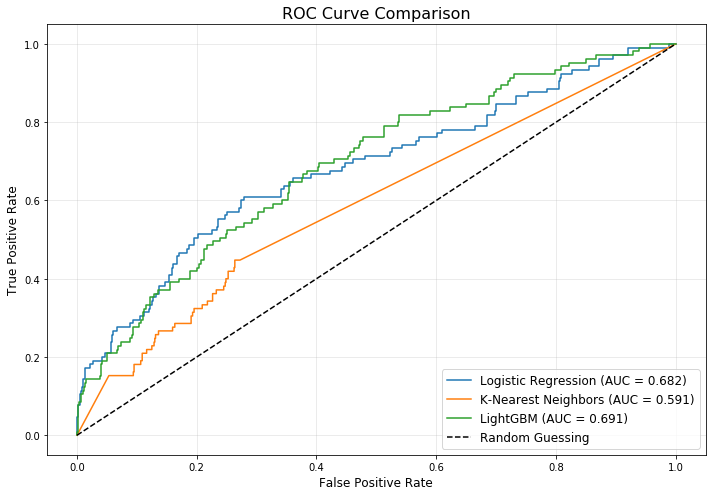


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.93      0.72      0.81       808
           1       0.22      0.61      0.32       105

    accuracy                           0.71       913
   macro avg       0.58      0.66      0.57       913
weighted avg       0.85      0.71      0.76       913


--- Classification Report: K-Nearest Neighbors ---
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       808
           1       0.19      0.27      0.22       105

    accuracy                           0.79       913
   macro avg       0.55      0.56      0.55       913
weighted avg       0.82      0.79      0.80       913


--- Classification Report: LightGBM ---
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       808
           1       0.56      0.13      0.22       105

    accuracy                         

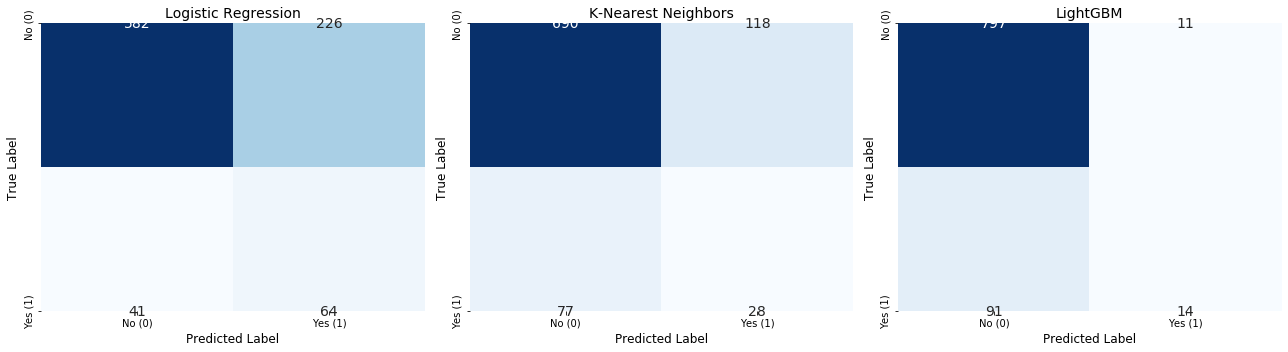

In [3]:
# Create a dictionary of trained, optimized models
models = {
    'Logistic Regression': best_lr,
    'K-Nearest Neighbors': best_knn,
    'LightGBM': best_lgbm
}

# ==========================================
# Visualization 1: Unified ROC Curve
# ==========================================
plt.figure(figsize=(10, 7))

for name, model in models.items():
    # 1. Predict probabilities for the test set
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    # 2. Calculate the AUC score
    auc_score = roc_auc_score(y_test, y_pred_prob)
    
    # 3. Calculate False Positive Rate and True Positive Rate for the curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    
    # 4. Plot the curve with the AUC score in the legend
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# Plot the random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('ROC Curve Comparison', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# Visualization 2: Side-by-Side Confusion Matrices
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    # Get hard predictions (0 or 1)
    y_pred = model.predict(X_test)
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot using seaborn heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 14})
    ax.set_title(f'{name}', fontsize=14)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xticklabels(['No (0)', 'Yes (1)'])
    ax.set_yticklabels(['No (0)', 'Yes (1)'])
    
    
    print(f"\n--- Classification Report: {name} ---")
    print(classification_report(y_test, y_pred))

plt.tight_layout()
plt.show()

## Retry Hyper-parameter tuning, this time optimizing for ROC-AUC instead of F1 score

- while F1-score forces the model to care about the default 50% threshold, ROC-AUC forces the model to become excellent at ranking probabilities.

- A model tuned on ROC-AUC will become  good at ensuring that a person who is actually going take up a product gets assigned a higher probability score (e.g., 0.8) than someone who isn't (e.g., 0.2).

In [4]:
# ==========================================
# 1. Logistic Regression Tuning
# ==========================================
print("Tuning Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10], # Regularization strength
    'solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=5, scoring='roc_auc')
lr_grid.fit(X_train_smote, y_train_smote)
best_lr_roc = lr_grid.best_estimator_

# ==========================================
# 2. K-Nearest Neighbors (K-NN) Tuning
# ==========================================
print("Tuning K-NN...")
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='roc_auc')
knn_grid.fit(X_train_smote, y_train_smote)
best_knn_roc = knn_grid.best_estimator_

# ==========================================
# 3. LightGBM Tuning
# ==========================================
print("Tuning LightGBM...")
lgbm_params = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    
    
    'num_leaves': [7,  15]
}
lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), lgbm_params, cv=5, scoring='roc_auc')
lgbm_grid.fit(X_train_smote, y_train_smote)
best_lgbm_roc = lgbm_grid.best_estimator_

print("\n--- Tuning Complete! ---")
print(f"Best LR Params: {lr_grid.best_params_}")
print(f"Best KNN Params: {knn_grid.best_params_}")
print(f"Best LGBM Params: {lgbm_grid.best_params_}")

Tuning Logistic Regression...
Tuning K-NN...
Tuning LightGBM...

--- Tuning Complete! ---
Best LR Params: {'C': 10, 'solver': 'liblinear'}
Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best LGBM Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'num_leaves': 15}


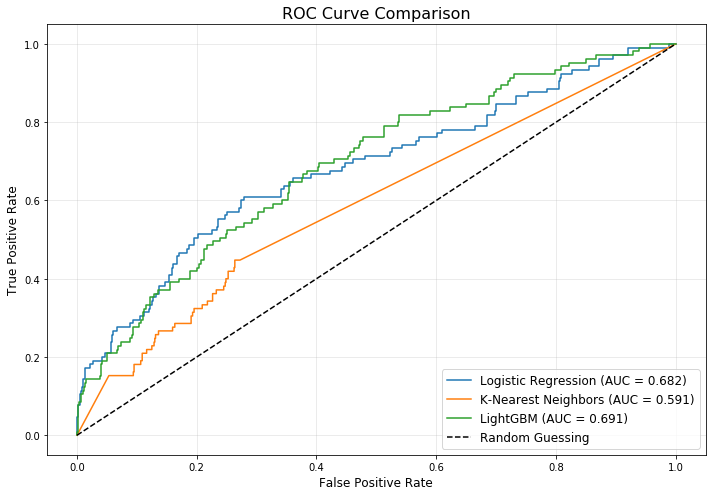


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.93      0.72      0.81       808
           1       0.22      0.61      0.32       105

    accuracy                           0.71       913
   macro avg       0.58      0.66      0.57       913
weighted avg       0.85      0.71      0.76       913


--- Classification Report: K-Nearest Neighbors ---
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       808
           1       0.19      0.27      0.22       105

    accuracy                           0.79       913
   macro avg       0.55      0.56      0.55       913
weighted avg       0.82      0.79      0.80       913


--- Classification Report: LightGBM ---
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       808
           1       0.56      0.13      0.22       105

    accuracy                         

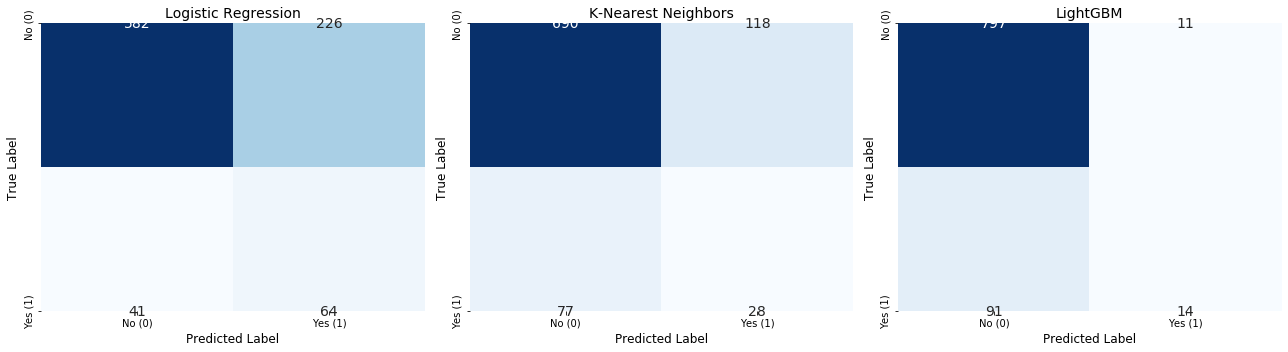

In [5]:
# Create a dictionary of trained, optimized models
models = {
    'Logistic Regression': best_lr,
    'K-Nearest Neighbors': best_knn,
    'LightGBM': best_lgbm
}

# ==========================================
# Visualization 1: Unified ROC Curve
# ==========================================
plt.figure(figsize=(10, 7))

for name, model in models.items():
    # 1. Predict probabilities for the test set
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    # 2. Calculate the AUC score
    auc_score = roc_auc_score(y_test, y_pred_prob)
    
    # 3. Calculate False Positive Rate and True Positive Rate for the curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    
    # 4. Plot the curve with the AUC score in the legend
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# Plot the random guessing baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('ROC Curve Comparison', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# Visualization 2: Side-by-Side Confusion Matrices
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    # Get hard predictions (0 or 1)
    y_pred = model.predict(X_test)
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot using seaborn heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 14})
    ax.set_title(f'{name}', fontsize=14)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xticklabels(['No (0)', 'Yes (1)'])
    ax.set_yticklabels(['No (0)', 'Yes (1)'])
    
    # Print out the classification report
    print(f"\n--- Classification Report: {name} ---")
    print(classification_report(y_test, y_pred))

plt.tight_layout()
plt.show()

## save fitted models

In [6]:
import joblib
import os

# 1. Create a dedicated folder 
os.makedirs('saved_models', exist_ok=True)

# ==========================================
# 2. Save the F1-Optimized Models
# ==========================================
print("Saving F1-optimized models...")
joblib.dump(best_lr, 'saved_models/lr_f1_best.joblib')
joblib.dump(best_knn, 'saved_models/knn_f1_best.joblib')
joblib.dump(best_lgbm, 'saved_models/lgbm_f1_best.joblib')

# ==========================================
# 3. Save the ROC-AUC-Optimized Models
# ==========================================
print("Saving ROC-AUC-optimized models...")
joblib.dump(best_lr_roc, 'saved_models/lr_roc_best.joblib')
joblib.dump(best_knn_roc, 'saved_models/knn_roc_best.joblib')
joblib.dump(best_lgbm_roc, 'saved_models/lgbm_roc_best.joblib')

print("All models successfully saved to the /saved_models/ directory! 🚀")

Saving F1-optimized models...
Saving ROC-AUC-optimized models...
All models successfully saved to the /saved_models/ directory! 🚀


# modify threshold

In [7]:
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

models = {'Logistic Regression': best_lr_roc, 'K-Nearest Neighbors': best_knn_roc, 'LightGBM': best_lgbm_roc}

print("==================================================")
print("🏆 OPTIMAL THRESHOLD TUNING & RESULTS 🏆")
print("==================================================\n")

for name, model in models.items():
    # 1. Get  raw probabilities for the positive class (1)
    y_pred_probs = model.predict_proba(X_test)[:, 1]
    
    # 2. Generate precision, recall, and thresholds arrays
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs)
    
    # 3. Calculate the F1 score for every threshold
    # (Adding 1e-10 prevents division-by-zero if precision and recall are both 0)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
    
    # 4. Find the index of the highest F1 score 
    best_index = np.argmax(f1_scores[:-1]) 
    optimal_threshold = thresholds[best_index]
    
    # 5. Apply the optimal threshold to get hard predictions
    y_pred_optimal = np.where(y_pred_probs >= optimal_threshold, 1, 0)
    
  
    print(f"--- Model: {name} ---")
    print(f"🔥 Optimal Threshold: {optimal_threshold:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_optimal))
    print("-" * 50 + "\n")

🏆 OPTIMAL THRESHOLD TUNING & RESULTS 🏆

--- Model: Logistic Regression ---
🔥 Optimal Threshold: 0.559
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       808
           1       0.27      0.50      0.35       105

    accuracy                           0.79       913
   macro avg       0.60      0.66      0.61       913
weighted avg       0.85      0.79      0.82       913

--------------------------------------------------

--- Model: K-Nearest Neighbors ---
🔥 Optimal Threshold: 0.218
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.64      0.76       808
           1       0.18      0.60      0.27       105

    accuracy                           0.63       913
   macro avg       0.55      0.62      0.51       913
weighted avg       0.84      0.63      0.70       913

--------------------------------------------------

--- Model: LightGBM ---
🔥 Optima

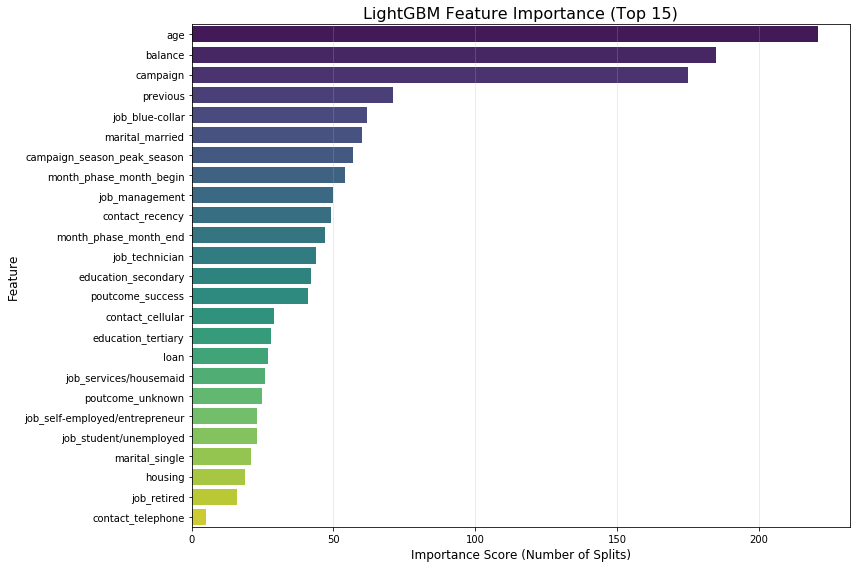

In [8]:
# 1. Extract feature importances and names from the final model
importances = best_lgbm_roc.feature_importances_
feature_names = X_train_smote.columns

# 2. Create a DataFrame and sort it by importance
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

plt.title('LightGBM Feature Importance (Top 15)', fontsize=16)
plt.xlabel('Importance Score (Number of Splits)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Load ROC-AUC Models
#best_lgbm_roc = joblib.load('saved_models/lgbm_roc_best.joblib')

Calculating SHAP values... (this takes a few seconds)


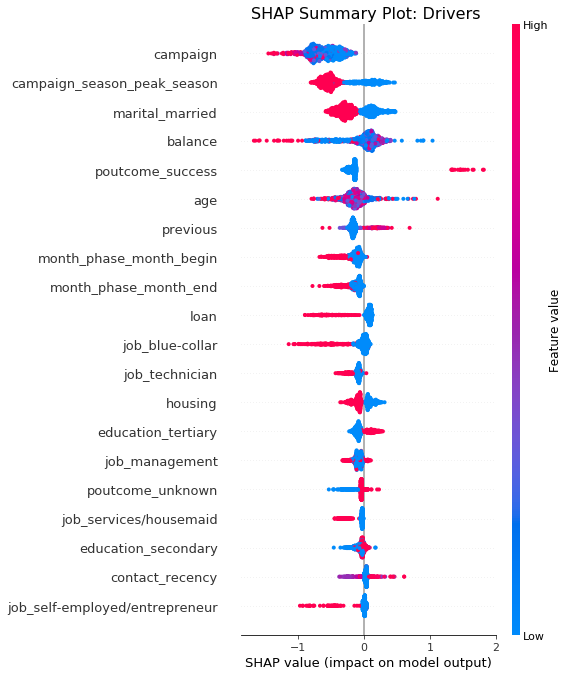

In [12]:
# 1. Initialize the SHAP Explainer specifically optimized for Tree models
explainer = shap.TreeExplainer(best_lgbm_roc)

# 2. Calculate SHAP values using the test set
print("Calculating SHAP values... (this takes a few seconds)")
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# 3. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_class1, X_test, plot_type="dot", show=False)

plt.title("SHAP Summary Plot: Drivers ", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Drivers of Conversion (Feature Importance)

##### "An analysis of the LightGBM feature importance reveals three distinct pillars driving predictions:

- Financial Capacity (age, balance): Demographic wealth indicators are the undisputed primary drivers.

- Campaign Execution (campaign, contact_recency): Operational metrics are highly predictive, indicating that the frequency and recency of touchpoints heavily influence the customer's decision. 

- Temporal Liquidity (month_phase, campaign_season): The custom-engineered chronological features proved highly valuable, outperforming traditional demographic variables like housing status or occupation

# Choice of evaluation metric

- Recall was prioritized as a primary evaluation metric because the business cost of a False Negative (failing to call a customer who would have purchased a term deposit) represents a direct loss of significant revenue. Maximizing Class 1 Recall ensures the campaign casts a wide enough net to capture the majority of the available market."
    
- While casting a wide net is important, Precision was actively monitored to protect call center efficiency. A model with extremely low precision would flood the agents with False Positives (calling non-buyers), leading to wasted operational hours and agent burnout. Precision acts as the operational guardrail for the campaign

- For the hyperparameter tuning phase, the F1-Score (for Class 1) was selected as the optimization metric. Because F1-Score calculates the harmonic mean of Precision and Recall, it forced the algorithms to find a mathematically balanced model that could successfully identify the rare minority class without generating an unacceptable volume of false alarms."

## Recommended Model: LightGBM (tuned to optimize roc-auc and with threshold optimization) - "best_lgbm_roc"

- For this telemarketing conversion problem, the LightGBM model optimized with a 0.218 decision threshold is the most appropriate solution.

- From a business perspective, it delivers the highest impact, achieving a recall of 0.52. This ensures we capture over half of the available market while operating at a 27% precision rate—a 132% efficiency increase over the historical campaign baseline.

- Technically, LightGBM outperforms the alternatives in both scalability and interpretability. Unlike K-Nearest Neighbors, which scales poorly and acts as a 'black box', LightGBM handles massive datasets efficiently and provides clear feature importance metrics. This allows us to transparently explain to marketing stakeholders exactly which customer behaviors (such as past campaign success and current account balance) are driving the predictions, fostering trust and enabling more personalized call scripts. Finally, its tree-based architecture inherently ignores noisy features and captures non-linear relationships without the strict multicollinearity concerns that constrain Logistic Regression."

# Business Impact for stakeholders

# 2. The Business Translation: "For every 100 calls..."


- To understand the true business value of deploying the threshold-optimized LightGBM model, we must compare it against the historical baseline of the campaign.

- The Baseline Approach (No Model): Historically, the campaign operates at an 11.6% conversion rate. This means if the call center dials 100 random customers, they successfully open 11.6 new term deposits.

- The LightGBM Approach: The optimized LightGBM model (threshold 0.218) operates with a Precision of 27%. This means if the call center dials 100 customers specifically recommended by the model, they will successfully takeup/sell 27 new products.

- Conclusion: By switching from a blind-calling strategy to a model-driven targeted strategy, we increase the call center's efficiency by 132% (from 11.6 to 27 successes per 100 calls). The agents make the exact same number of phone calls, but generate nearly double the revenue. Furthermore, with a Recall of 52%, the model ensures we are still capturing over half of the entire available market of buyers in the dataset.

## Reasoning and recommendation

### 1. Assumptions

### Financial Cost-Benefit Assumption:
- We mathematically assumed that the financial reward of securing a new term deposit (True Positive) vastly outweighs the operational cost of a failed phone call (False Positive). This assumption directly drove the decision to lower the decision threshold to 0.218, prioritizing Recall over Precision.

### Temporal Stability: 
- By engineering features like month_phase_mid_month and campaign_season, we are assuming that customer financial psychology (e.g., mid-month liquidity) remains stable year-over-year. We assume macroeconomic factors (like sudden inflation or interest rate hikes) won't radically change when customers have spare cash.

### Data Integrity of 'Unknowns':
- When handling the poutcome variable, we assumed that grouping the ambiguous other category into the unknown category was safe, assuming these represented customers with no meaningful prior relationship with the bank, rather than a hidden technical failure in data collection.

### The future will look like the past - an assumption all predictive models make



### 2. Based on the results, which clients would you recommend targeting in future campaigns?


#### Based on shapley plot and feature importances:

- People with lower balances, single , previous campaign success, mid-month, doesnt have a loan, is not blue collar, does not have a house loan, has tertiary education, management job etc

- High-Liquidity Demographics: The model overwhelmingly prioritizes age and balance. The campaign should target older demographics who have accumulated higher bank balances, as they are the primary demographic looking for low-risk, capital-heavy wealth management tools.

- Proven Brand Loyalists: Customers flagged with poutcome_success should be prioritized immediately. Past conversion behavior is a massive indicator of future conversion behavior.

- The "Mid-Month" Window: Target customers dynamically based on the calendar. Call volumes should surge during the mid_month phase (days 10-20) when payroll cycles typically grant customers fresh liquidity.

- Low-Fatigue Leads: Customers with a low campaign count (those who have not been repeatedly called during this cycle). The model recognizes that over-contacting a customer rapidly diminishes the probability of a sale.

### 3. Highlight any trade-offs

- Recall vs. Precision (The Business Trade-off): To achieve a 52% Recall (capturing over half the market of true buyers), we deliberately accepted a lower Precision of 27%. The trade-off is call center efficiency. The agents will have to dial more false positives to ensure we don't miss the highly lucrative true positives.

- Interpretability vs. Predictive Power (The Model Trade-off): We selected LightGBM over Logistic Regression. We traded the absolute transparency of linear coefficients (knowing exact log-odds changes) for a highly complex ensemble model. While we lose some direct interpretability, we gain massive predictive power and the ability to capture non-linear relationships without manually engineering interaction terms.

- Synthetic Data vs. Real Distributions: By utilizing SMOTE, we traded the true mathematical distribution of the training data for a synthetic, balanced distribution. This forced the model to learn the minority class but inherently distorted the raw probability outputs, requiring manual threshold tuning to align back with reality.

### 4. Suggest further steps to improve model reliability or robustness


- Probability Calibration: Because SMOTE artificially inflates the number of positive targets during training, LightGBM's raw probability outputs (e.g., 0.60) do not reflect true real-world probabilities. Applying Platt Scaling or Isotonic Regression via Scikit-Learn’s CalibratedClassifierCV would map these outputs back to highly accurate, real-world confidence percentages for the marketing team.

- Production A/B Testing: Before fully replacing the legacy system, the model should be deployed in a "shadow mode" or live A/B test. We would randomly route 20% of the daily call center leads using the LightGBM recommendations and compare the conversion rate against the 80% baseline to empirically prove the 132% efficiency lift in a live environment.

- Feature Pruning: Drop the bottom 20% of features (like contact_telephone or irrelevant job categories) to reduce the dimensionality of the dataset. A leaner model is faster to score in production, less prone to overfitting, and easier to maintain when data drift inevitably occurs.

# Optional for discussion

### 1. Batch vs. Real-Time Deployment Scenarios

- Batch Processing (The Call Center Lead List). As an example, every night at 2:00 AM, the data engineering team runs a batch pipeline that scores the entire customer database using the LightGBM model. The output is a ranked CSV file of customers whose probability score is above your 0.182 threshold. When the call center agents log in at 8:00 AM, their daily dialing software is already pre-populated with these high-value targets. The benefits of this approach are that it is  computationally cheap, easy to schedule, and does not require millisecond-level latency.

- Real-Time Deployment. The model is deployed behind a REST API (using a tool like FastAPI or AWS SageMaker). As an example,  a customer logs into the bank's mobile app or calls into the customer service center for a routine inquiry. The app immediately sends their live data (e.g., current balance, time of month) to the API. In milliseconds, the API returns a score. If the score is 0.218 the mobile app instantly displays a banner ad for a Term Deposit, or the customer service agent gets a pop-up on their screen saying, "Selling opportunity!". The benefit of this approach is that it captures immediate customer intent and most recent data available, but it requires highly complex engineering.

### 2. Monitoring Model Performance and Data Drift

- Monitoring Performance (Concept Drift). Concept drift happens when the underlying human behavior changes. Continuously track the model's Precision and Recall in production. If performance drops, the model might have degraded and needs to be retrained on fresh data. Also investigate distribution of the population model is used on. Has it changed from what the model was developed on?

- Monitoring Data Drift (Feature Drift). Data drift happens when the input variables change.Implement a metric like the Population Stability Index (PSI) or use the Kolmogorov-Smirnov (KS) test. These tests compare the distribution of the data the model was trained on against the newest data coming in. If the distributions diverge past a certain threshold, an automated alert is sent to the Data Science team to investigate.

### 3. Ethical Considerations (Systematic Exclusion)

- Implement an "Explore and Exploit" strategy.Exploit (80-90%): Use the LightGBM model to call the highest probability targets to ensure business revenue.Explore (10-20%): Dedicate a portion of the call center's time to randomly sample demographics that the model currently ignores (e.g., younger clients). This ensures equitable access to financial products and generates fresh, unbiased data so the model can eventually learn how to successfully market to these excluded groups.